In [1]:
# Import the package from the parent directory
import sys
import os
sys.path.insert(0, os.path.dirname(os.getcwd()))  # noqa

In [2]:
import torch
from src import TerrainDiffusionPipeline, load_tile, tensor_to_img

# Load pipeline
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
pipeline = TerrainDiffusionPipeline.from_pretrained(
    '../models/diffusion/sketch-to-terrain/final',
).to(device)

In [3]:
# Set parameters
timesteps = 50
guidance_scale = 1
seed = 42
use_fp16 = True

# Load tile
tile_dir = '../data/examples/16_24959_10284_3'
tile = load_tile(tile_dir)

In [4]:
# Generate terrain
with torch.autocast(device_type=device.type, enabled=use_fp16):
    outputs = pipeline(
        cond_image=tile['sketch'].to(device),
        terrain_style=tile['style'].to(device),
        num_inference_steps=timesteps,
        guidance_scale=guidance_scale,
        seed=seed
    ).images

# Normalize outputs (from [-1, 1] to [0, 1])
outputs = (outputs + 1)/2


  0%|          | 0/50 [00:00<?, ?it/s]

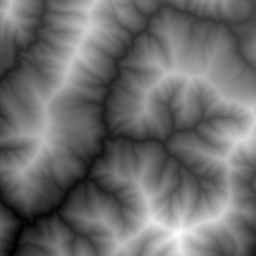

In [5]:
# Display the first image
output_image = tensor_to_img(outputs[0], bit_depth=16)
output_image

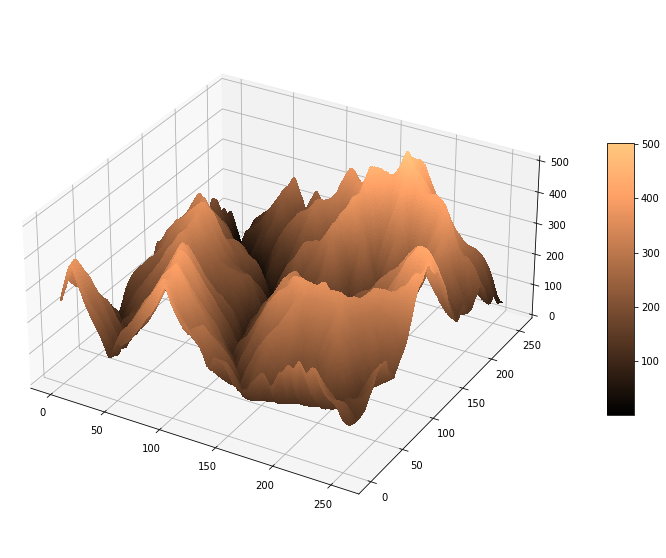

In [6]:
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np

height = tile['range'][0]

plt.rcParams['figure.figsize'] = [20, 10]

fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

X, Y = np.meshgrid(np.arange(256), np.arange(256))
Z = outputs[0][0].cpu().numpy() * height

# Plot the surface.
surf = ax.plot_surface(
    X, Y, Z,
    cmap=cm.copper,
    linewidth=0,
    antialiased=False,
    rcount=256,
    ccount=256,
)

# Add a color bar which maps values to colors.
fig.colorbar(surf, shrink=0.5, aspect=10)
ax.set_box_aspect((1, 1, 256/height))

plt.show()